In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

# --- CONFIGURATION DES MODULES M2 ---
modules_s3 = ["UML", "Oracle 2", "Math", "Deep Learning", "JupyterNotebook", "Soft Skills 2"]
modules_s4 = ["Projet Tutorial 1", "Projet Tutorial 2", "Stage PFE 1", "Stage PFE 2"]
all_modules_m2 = modules_s3 + modules_s4

# Dataset M2 : 20 étudiants, 10 modules
X_m2 = np.random.randint(5, 20, size=(20, 10))

# Labels Master : 1 (Admis), 0 (Rattrapage), -1 (Échec)
y_m2 = np.array([1 if np.mean(e) >= 12 else (0 if np.mean(e) >= 10 else -1) for e in X_m2])

In [2]:
def entropy(y):
    # H(S) = -Σ p_i * log2(p_i)
    counts = Counter(y)
    probs = [c/len(y) for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)

def split_info(y_subsets):
    # SplitInfo(S, A) = -Σ (|Si|/|S|) * log2(|Si|/|S|)
    # Mesure l'information intrinsèque de la division
    total = sum(len(s) for s in y_subsets)
    return -sum((len(s)/total) * math.log2(len(s)/total) for s in y_subsets if len(s) > 0)

def calculate_c45_gain_ratio(X, y, features):
    h_s = entropy(y)
    ratios = []
    print(f"--- ANALYSE C4.5 (MASTER 2) ---")

    for i in range(X.shape[1]):
        mask = X[:, i] < 10
        groups = [y[mask], y[~mask]]

        # Gain d'information classique
        gain = h_s - sum((len(g)/len(y)) * entropy(g) for g in groups)

        # Split Information (La normalisation C4.5)
        si = split_info(groups)

        # Gain Ratio = Gain / SplitInfo
        # Math : Empêche le surapprentissage sur les variables à forte cardinalité
        ratio = gain / si if si != 0 else 0
        ratios.append(ratio)
        print(f"{features[i]:18} : Gain Ratio = {round(ratio, 4)}")

    return np.argmax(ratios)

best_m2_idx = calculate_c45_gain_ratio(X_m2, y_m2, all_modules_m2)

--- ANALYSE C4.5 (MASTER 2) ---
UML                : Gain Ratio = 0.0506
Oracle 2           : Gain Ratio = 0.0607
Math               : Gain Ratio = 0.0
Deep Learning      : Gain Ratio = 0.3881
JupyterNotebook    : Gain Ratio = 0.0
Soft Skills 2      : Gain Ratio = 0.0145
Projet Tutorial 1  : Gain Ratio = 0.0605
Projet Tutorial 2  : Gain Ratio = 0.0506
Stage PFE 1        : Gain Ratio = 0.0206
Stage PFE 2        : Gain Ratio = 0.1737


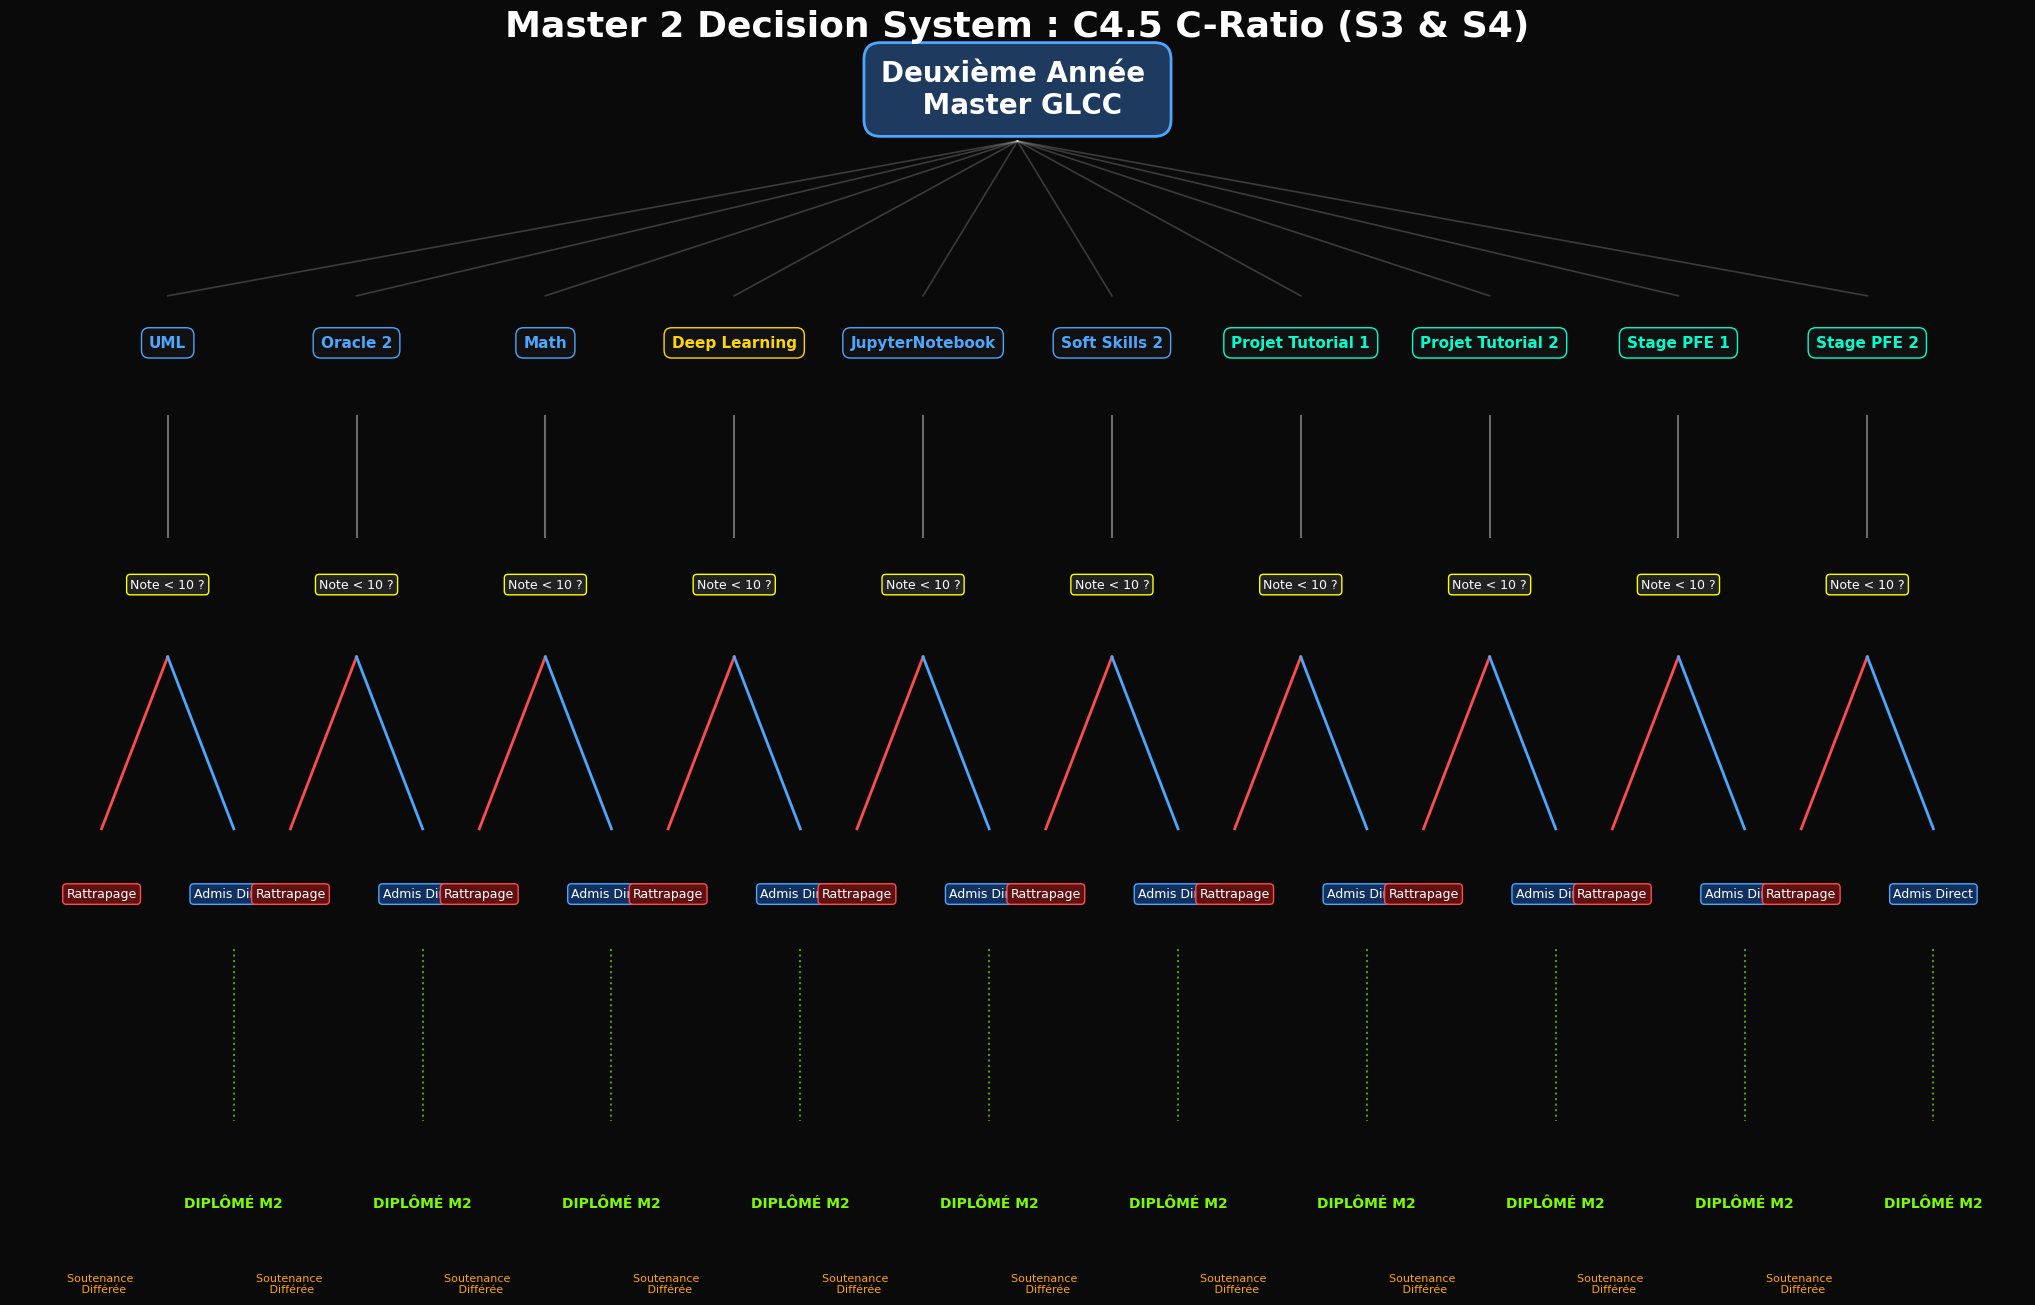

In [3]:
def visualize_master_m2_tree(best_idx):
    fig, ax = plt.subplots(figsize=(26, 14))
    fig.patch.set_facecolor("#0A0A0A")
    ax.set_facecolor("#0A0A0A")
    ax.axis('off')

    plt.title("Master 2 Decision System : C4.5 C-Ratio (S3 & S4)", color='white', fontsize=26, fontweight='bold', pad=40)

    # Racine Master 2
    ax.text(0.5, 0.95, "Deuxième Année \n Master GLCC", ha='center', va='center', fontsize=20, color='white', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#1E3A5F", edgecolor="#4DA6FF", linewidth=2))

    pos_modules = np.linspace(0.05, 0.95, len(all_modules_m2))

    for i, mod_name in enumerate(all_modules_m2):
        x = pos_modules[i]
        is_best = (i == best_idx)
        # S3 (Bleu), S4 (Vert/Cyan), Best (Or)
        color_theme = "#FFD700" if is_best else ("#4DA6FF" if i < 6 else "#00FFCC")

        # Branche Racine -> Module
        ax.plot([0.5, x], [0.92, 0.83], color='white', linewidth=1.2, alpha=0.2)

        # Noeud Module
        ax.text(x, 0.80, mod_name, ha='center', fontsize=11, fontweight='bold', color=color_theme,
                bbox=dict(facecolor='#111', edgecolor=color_theme, boxstyle='round,pad=0.5'))

        # Logique de Décision
        ax.plot([x, x], [0.76, 0.69], color='white', alpha=0.4)
        ax.text(x, 0.66, "Note < 10 ?", ha='center', fontsize=9, color='white',
                bbox=dict(boxstyle="round", facecolor='#222', edgecolor='yellow'))

        xl, xr = x-0.035, x+0.035
        # BRANCHE RATTRAPAGE (ROUGE)
        ax.plot([x, xl], [0.62, 0.52], color='#FF4D4D', linewidth=2)
        ax.text(xl, 0.48, "Rattrapage", ha='center', color='white', size=9,
                bbox=dict(boxstyle="round", facecolor='#601010', edgecolor='#FF4D4D'))

        # Annotation spécifique M2 : Diplôme en attente
        ax.annotate('', xy=(xl, 0.30), xytext=(xl, 0.45),
                    arrowprops=dict(arrowstyle='->', color='orange', linestyle='--'))
        ax.text(xl, 0.25, "Soutenance \n Différée", ha='center', color='orange', size=8)

        # BRANCHE RÉUSSITE (BLEU/VERT)
        ax.plot([x, xr], [0.62, 0.52], color='#4DA6FF', linewidth=2)
        ax.text(xr, 0.48, "Admis Direct", ha='center', color='white', size=9,
                bbox=dict(boxstyle="round", facecolor='#103060', edgecolor='#4DA6FF'))

        # Annotation finale : DIPLÔME OBTENU
        ax.plot([xr, xr], [0.45, 0.35], color='#7CFC00', alpha=0.6, linestyle=':')
        ax.text(xr, 0.30, "DIPLÔMÉ M2", ha='center', color='#7CFC00', fontweight='bold', size=10)

    plt.show()

visualize_master_m2_tree(best_m2_idx)